In [1]:
!pip install pandas numpy matplotlib seaborn nltk tqdm datasets scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 16.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from tqdm import tqdm
from datasets import load_dataset, load_from_disk

In [3]:
from huggingface_hub import login

login()

In [3]:
# Load dataset
dataset_large = load_dataset("JohanHeinsen/ENO", split='train')

df = dataset_large.to_pandas()
df.shape

README.md: 0.00B [00:00, ?B/s]

ENO.csv:   0%|          | 0.00/3.40G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4898084 [00:00<?, ? examples/s]

(4898084, 5)

In [6]:
df.head()

,text,date,id,pwa,newspaper
0,Et Menneske er skabt ey for sig selv allene: H...,1767-01-02,aalborg1767_1767-01-02_1000001,0.98480,Jyske Efterretninger
1,Et Moralsk Ugeblad finder i sær mange forskiel...,1767-01-02,aalborg1767_1767-01-02_1000002,0.98947,Jyske Efterretninger
2,"De af vore Læsere, der finde Behag i at gjøre ...",1767-01-02,aalborg1767_1767-01-02_1000003,0.95652,Jyske Efterretninger
3,Dødsfald. Den 26. Decembr. sidst døde her i By...,1767-01-02,aalborg1767_1767-01-02_1000005,1.00000,Jyske Efterretninger
4,"Den 27 ejusd. døde Sr. Matthias Matthiesen, Re...",1767-01-02,aalborg1767_1767-01-02_1000006,1.00000,Jyske Efterretninger


In [7]:
df['newspaper'].value_counts()

newspaper
Københavns Adresseavis                           1377081
Berlingske Tidende                                792663
Odense Adresse-Contoirs Efterretninger            520007
Aarhuus Stifts-Tidende                            365738
Viborger Samler                                   344020
Ribe Stifts Adresseaviser                         238260
Aalborg Stiftstidende                             203072
Norske Intelligenssedler                          175327
Lolland-Falsters Stifts-Tidende                   163765
Jyske Efterretninger                              150227
Den Vest-Sjællandske Avis                         132439
Den Nord-Cimbriske Tilskuer                        94609
Efterretninger fra Adresse-Contoiret i Bergen      86338
Nyeste Skilderie af Kiøbenhavn                     73059
Aalborgs Stifts Adresseavis                        62540
Kiøbenhavns Postrytter                             46860
Tronhiems Adresse-Contoirs Efterretninger          33808
Extraordinaire Maaned

In [9]:
print(df['date'].min(), df['date'].max())

1666-07-01 1849-12-31


In [4]:
unique_newspapers = df['newspaper'].unique()

In [14]:
records = []

for newspaper in unique_newspapers:
    subs = df[df['newspaper'] == newspaper]
    records.append({
        'newspaper': newspaper,
        'first_date': subs['date'].min(),
        'last_date': subs['date'].max(),
        'length': len(subs)
    })

result_df = pd.DataFrame(records)

In [16]:
result_df = result_df[result_df['length'] >= 10000]

In [17]:
result_df

,newspaper,first_date,last_date,length
0,Jyske Efterretninger,1767-01-02,1823-12-29,150227
1,Aalborgs Stifts Adresseavis,1818-01-29,1827-03-31,62540
2,Aalborg Stiftstidende,1827-04-02,1846-12-30,203072
3,Aarhuus Stifts-Tidende,1794-01-03,1847-12-29,365738
4,Københavns Adresseavis,1759-02-01,1837-12-30,1377081
7,Efterretninger fra Adresse-Contoiret i Bergen,1765-02-04,1814-12-31,86338
8,Berlingske Tidende,1749-01-03,1836-12-31,792663
16,Kiøbenhavns Postrytter,1733-01-02,1798-06-29,46860
17,Lolland-Falsters Stifts-Tidende,1809-03-07,1847-12-30,163765
18,Nyeste Skilderie af Kiøbenhavn,1803-10-17,1831-03-31,73059


/tmp/ipykernel_1284/1912712698.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df["first_date"] = pd.to_datetime(result_df["first_date"])
/tmp/ipykernel_1284/1912712698.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df["last_date"] = pd.to_datetime(result_df["last_date"])


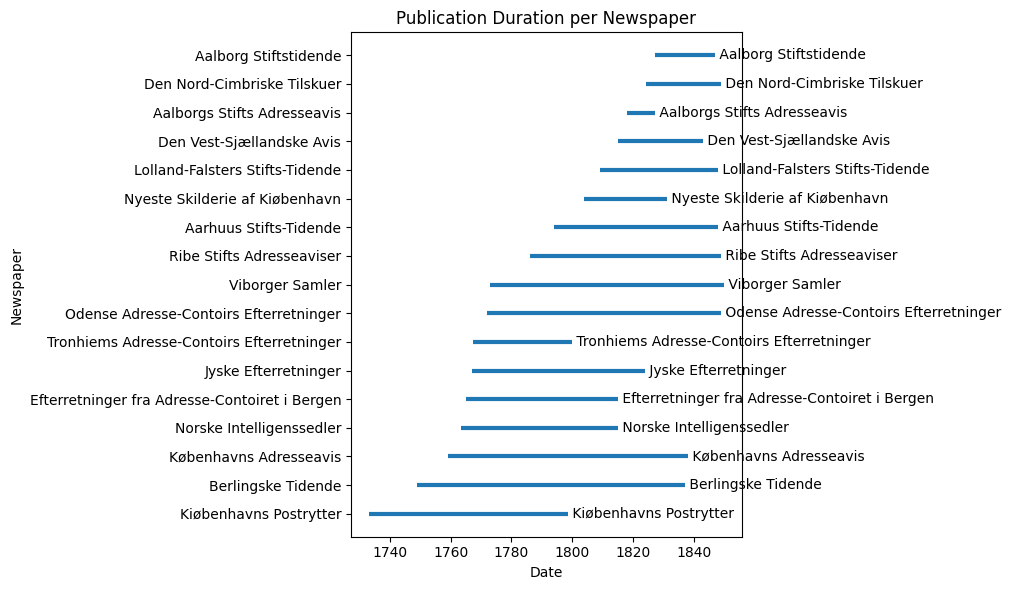

In [18]:
import matplotlib.pyplot as plt

# make sure dates are datetime
result_df["first_date"] = pd.to_datetime(result_df["first_date"])
result_df["last_date"] = pd.to_datetime(result_df["last_date"])

# sort newspapers by first_date (optional, just for readability)
result_df = result_df.sort_values("first_date")

plt.figure(figsize=(10, 6))

for i, row in enumerate(result_df.itertuples()):
    plt.hlines(
        y=i,
        xmin=row.first_date,
        xmax=row.last_date,
        color="tab:blue",
        linewidth=3
    )
    plt.text(row.last_date, i, f" {row.newspaper}", va="center")

plt.yticks(range(len(result_df)), result_df["newspaper"])
plt.xlabel("Date")
plt.ylabel("Newspaper")
plt.title("Publication Duration per Newspaper")
plt.tight_layout()
plt.show()

In [4]:
# take random sample of 500 per newspaper
sampled_df = (
    df.groupby("newspaper", group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=42)
)
)

print(sampled_df.shape)
print(sampled_df["newspaper"].value_counts())

(14000, 5)
newspaper
Aalborg Stiftstidende                            500
Aalborgs Stifts Adresseavis                      500
Aarhuus Stifts-Tidende                           500
Adresseavis for Børn                             500
Almuevennen                                      500
Berlingske Tidende                               500
Corsaren                                         500
Danske Mercurius                                 500
Den Nord-Cimbriske Tilskuer                      500
Den Vest-Sjællandske Avis                        500
Efterretninger fra Adresse-Contoiret i Bergen    500
Extraordinaire Maanedlige Relationer             500
Extraordinaire Relationer                        500
Jyllandsposten                                   500
Jyske Efterretninger                             500
Kiøbenhavns Extraordinaire Relation              500
Kiøbenhavns Maanetlige Postrytter                500
Kiøbenhavns Postrytter                           500
Københavns Adresseavis   

/tmp/ipykernel_4486/2477608481.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("newspaper", group_keys=False).apply(


In [5]:
sampled_df.head()

,text,date,id,pwa,newspaper
286506,Efter Begjæring af Hr. Proprietair v. Bülow bl...,1835-07-09,aalborg1827_1835-07-09_1086679,0.98131,Aalborg Stiftstidende
294663,Det er dette Blads Redaction behageliget herve...,1836-07-02,aalborg1827_1836-07-02_1096266,0.98286,Aalborg Stiftstidende
248365,Blandinger. Ved kongelig Resolution af 12te Ja...,1831-05-11,aalborg1827_1831-05-11_1041531,0.96250,Aalborg Stiftstidende
241888,Dersom der nogensteds skulde anbydes til Salg ...,1830-08-25,aalborg1827_1830-08-25_1034127,0.95556,Aalborg Stiftstidende
216564,"J min Alderdoms trange Kaar, maae jeg nu bitte...",1827-09-17,aalborg1827_1827-09-17_1004375,0.97561,Aalborg Stiftstidende


In [7]:
sampled_df.to_csv('sample_500.csv', sep='\t')